In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Input, Dropout
from tensorflow.keras.optimizers import Adam

# --- CONFIGURATION ---
FILE_PATH = "data/hcmc_lstm_ready.csv"
TEST_SPLIT_DATE = '2022-01-01'

# 1. DATA PREPARATION
df = pd.read_csv(FILE_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

# Define Features (X) and Target (y)
target_col = 'value'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

print(f"Features: {feature_cols}")
print(f"Data Shape: {X.shape}")

# Split
split_idx = df.index.get_loc(TEST_SPLIT_DATE).start
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train Size: {len(X_train)} | Test Size: {len(X_test)}")

# Scale (Normalize to 0-1)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

# Reshape for LSTM
# LSTM needs 3D input: (Samples, TimeSteps, Features)
# Since we engineered lags manually, TimeSteps = 1
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

Features: ['lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_168h', 'roll_mean_24h', 'roll_std_24h', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
Data Shape: (37665, 13)
Train Size: 31304 | Test Size: 6361


In [3]:
# 2. MODEL 1: LINEAR REGRESSION
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_scaled)

# Predict
y_pred_lr_scaled = lr_model.predict(X_test_scaled)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_scaled) # Convert back to real PM2.5

In [4]:
# 3. MODEL 2: LSTM
lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
lstm_model.fit(X_train_lstm, y_train_scaled, epochs=10, batch_size=32, verbose=1, validation_split=0.1)

# Predict
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)

Epoch 1/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0014 - val_loss: 4.1443e-04
Epoch 2/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.7038e-04 - val_loss: 4.0548e-04
Epoch 3/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.4934e-04 - val_loss: 3.8123e-04
Epoch 4/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.7467e-04 - val_loss: 3.6213e-04
Epoch 5/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.9229e-04 - val_loss: 3.7869e-04
Epoch 6/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.7836e-04 - val_loss: 3.6299e-04
Epoch 7/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.0701e-04 - val_loss: 3.6597e-04
Epoch 8/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.5402e-04 - val_loss: 3.7685e-04
Epoch 9/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.6476e-04 - val_loss: 3.7474e-04
Epoch 10/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.4619e-04 - val_loss: 3.6980e-04
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [5]:
# 4. MODEL 3: Bi-LSTM
bilstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Bidirectional(LSTM(64, activation='relu', return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32, activation='relu', return_sequences=False)),
    Dropout(0.2),
    Dense(1)
])
bilstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
bilstm_model.fit(X_train_lstm, y_train_scaled, epochs=10, batch_size=32, verbose=1, validation_split=0.1)

# Predict
y_pred_bilstm_scaled = bilstm_model.predict(X_test_lstm)
y_pred_bilstm = scaler_y.inverse_transform(y_pred_bilstm_scaled)

Epoch 1/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 9.8709e-04 - val_loss: 3.9101e-04
Epoch 2/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 6.6682e-04 - val_loss: 3.7744e-04
Epoch 3/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.0538e-04 - val_loss: 3.5860e-04
Epoch 4/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.6910e-04 - val_loss: 3.6470e-04
Epoch 5/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.8730e-04 - val_loss: 3.6530e-04
Epoch 6/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.9093e-04 - val_loss: 3.5864e-04
Epoch 7/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 4.8847e-04 - val_loss: 3.5627e-04
Epoch 8/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.5058e-04 - val_loss: 3.6569e-04
Epoch 9/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.0403e-04 - val_loss: 3.6539e-04
Epoch 10/10
881/881 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.0932e-04 - val_loss: 3.5923e-04
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


[Linear Reg] MAE: 5.71 | RMSE: 8.54 | R2: 0.628
[LSTM] MAE: 5.62 | RMSE: 8.33 | R2: 0.646
[Bi-LSTM] MAE: 5.51 | RMSE: 8.32 | R2: 0.646


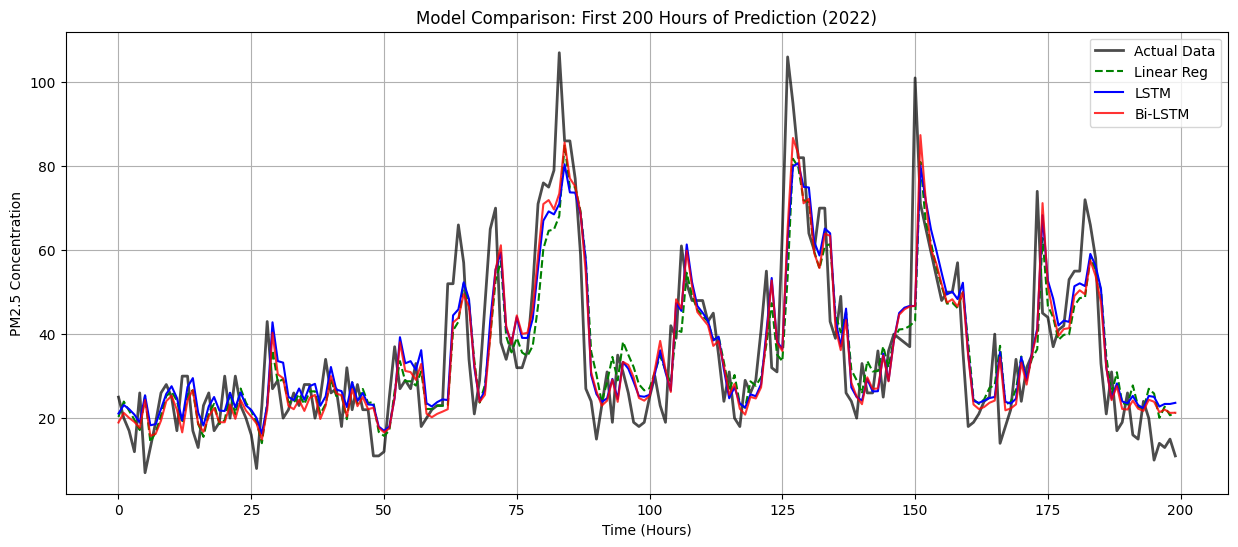

In [6]:
# 5. COMPARISON & EVALUATION
# Calculate Error Metrics
def get_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{name}] MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f}")
    return mae, rmse

lr_metrics = get_metrics(y_test, y_pred_lr, "Linear Reg")
lstm_metrics = get_metrics(y_test, y_pred_lstm, "LSTM")
bilstm_metrics = get_metrics(y_test, y_pred_bilstm, "Bi-LSTM")

# Plot first 200 hours of Test Data
plt.figure(figsize=(15, 6))
limit = 200

plt.plot(y_test[:limit], label='Actual Data', color='black', linewidth=2, alpha=0.7)
plt.plot(y_pred_lr[:limit], label='Linear Reg', linestyle='--', color='green')
plt.plot(y_pred_lstm[:limit], label='LSTM', color='blue')
plt.plot(y_pred_bilstm[:limit], label='Bi-LSTM', color='red', alpha=0.8)

plt.title('Model Comparison: First 200 Hours of Prediction (2022)')
plt.ylabel('PM2.5 Concentration')
plt.xlabel('Time (Hours)')
plt.legend()
plt.grid(True)
plt.show()